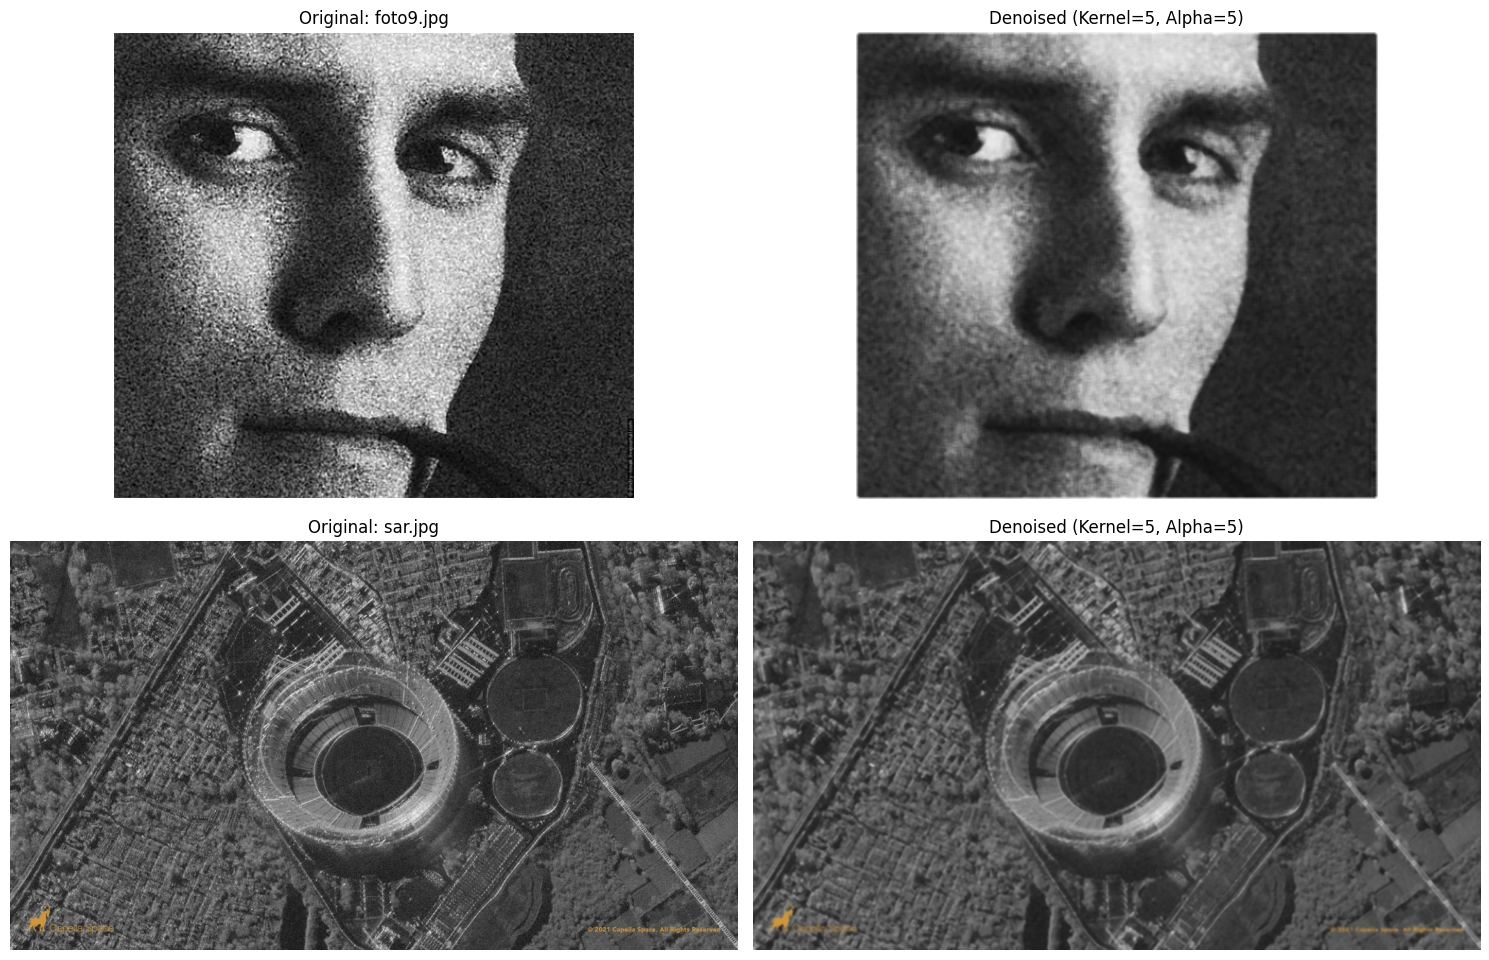

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def alpha_trimmed_mean_filter(image, kernel_size, alpha):
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be an odd number.")
    if not (0 <= alpha < (kernel_size * kernel_size) / 2):
        raise ValueError(f"Alpha must be between 0 and (kernel_size*kernel_size)/2. Current alpha: {alpha}")

    # Convert to float for processing
    img_float = image.astype(np.float32)
    rows, cols = img_float.shape[:2]
    output_image = np.zeros_like(img_float)

    pad_size = kernel_size // 2
    # Pad the image to handle borders
    padded_img = cv2.copyMakeBorder(img_float, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)

    for i in range(rows):
        for j in range(cols):
            if img_float.ndim == 2: # Grayscale image
                neighborhood = padded_img[i:i + kernel_size, j:j + kernel_size].flatten()
                # Sort and trim
                sorted_neighborhood = np.sort(neighborhood)
                trimmed_neighborhood = sorted_neighborhood[alpha:-alpha] if alpha > 0 else sorted_neighborhood
                output_image[i, j] = np.mean(trimmed_neighborhood)
            else: # Color image (assuming BGR channels)
                for c in range(image.shape[2]):
                    neighborhood = padded_img[i:i + kernel_size, j:j + kernel_size, c].flatten()
                    # Sort and trim
                    sorted_neighborhood = np.sort(neighborhood)
                    trimmed_neighborhood = sorted_neighborhood[alpha:-alpha] if alpha > 0 else sorted_neighborhood
                    output_image[i, j, c] = np.mean(trimmed_neighborhood)

    return np.clip(output_image, 0, 255).astype(np.uint8)


# List of image files
image_files = ['/content/foto9.jpg', '/content/sar.jpg']

# Filter parameters
KERNEL_SIZE = 5 # Must be an odd number (e.g., 3, 5, 7)
ALPHA_TRIM = 5  # Number of smallest and largest values to trim

plt.figure(figsize=(15, 5 * len(image_files)))

for idx, img_path in enumerate(image_files):
    try:
        # Load image
        img_original = cv2.imread(img_path)
        if img_original is None:
            print(f"Error: Could not load image {img_path}. Skipping.")
            continue

        # Convert BGR to RGB for matplotlib display
        img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

        # Apply the alpha-trimmed mean filter
        img_denoised = alpha_trimmed_mean_filter(img_original, KERNEL_SIZE, ALPHA_TRIM)
        img_denoised_rgb = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2RGB)

        # Display results
        plt.subplot(len(image_files), 2, 2 * idx + 1)
        plt.imshow(img_rgb)
        plt.title(f'Original: {img_path.split("/")[-1]}')
        plt.axis('off')

        plt.subplot(len(image_files), 2, 2 * idx + 2)
        plt.imshow(img_denoised_rgb)
        plt.title(f'Denoised (Kernel={KERNEL_SIZE}, Alpha={ALPHA_TRIM})')
        plt.axis('off')

    except Exception as e:
        print(f"An error occurred while processing {img_path}: {e}")

plt.tight_layout()
plt.show()
